<a href="https://colab.research.google.com/github/NehaMusale11/Machine-Vision/blob/main/Machine_VIsion_Practical_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install kagglehub opencv-contrib-python

In [4]:
import kagglehub
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

In [5]:
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Dataset Path:", path)

100%|██████████| 612M/612M [00:09<00:00, 64.9MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1


In [6]:
for root, dirs, files in os.walk(path):
    print(root)
    print("Folders:", dirs[:5])
    print("Files:", files[:5])
    print("---------------------")

/root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1
Folders: ['train', 'Meta', 'meta', 'Train', 'test']
Files: ['Meta.csv', 'Train.csv', 'Test.csv']
---------------------
/root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1/train
Folders: ['22', '28', '14', '8', '31']
Files: []
---------------------
/root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1/train/22
Folders: []
Files: ['00022_00009_00016.png', '00022_00005_00008.png', '00022_00005_00027.png', '00022_00003_00009.png', '00022_00005_00023.png']
---------------------
/root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1/train/28
Folders: []
Files: ['00028_00011_00006.png', '00028_00003_00015.png', '00028_00002_00018.png', '00028_00001_00011.png', '00028_00012_00000.png']
---------------------
/root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1/tr

In [7]:
image_path = None

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith((".png",".jpg",".jpeg")):
            image_path = os.path.join(root,file)
            break
    if image_path:
        break

print(image_path)

/root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1/train/22/00022_00009_00016.png


Text(0.5, 1.0, 'Road Sign')

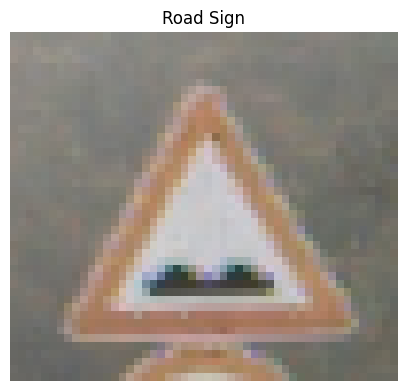

In [8]:
image = cv2.imread(image_path)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis("off")
plt.title("Road Sign")

Text(0.5, 1.0, 'Gray Image')

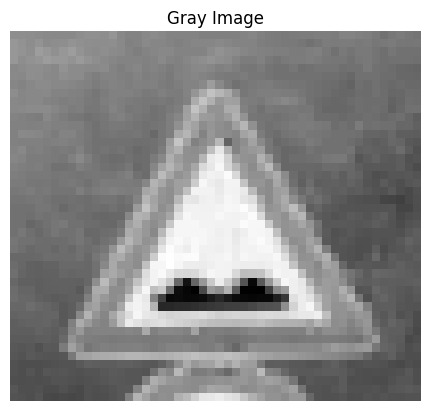

In [9]:
gray = cv2.cvtColor(image,cv2.COLOR_RGB2GRAY)

plt.imshow(gray,cmap='gray')
plt.axis("off")
plt.title("Gray Image")

Corners Detected: 33


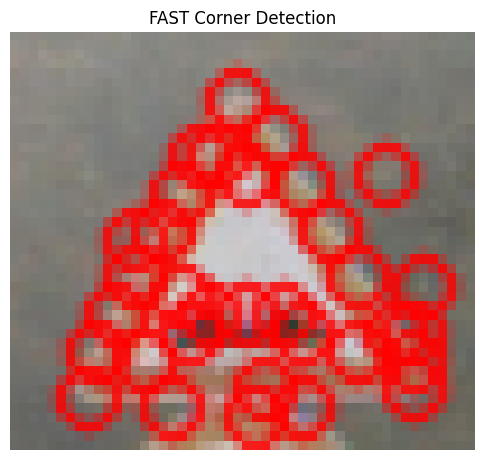

In [10]:
fast = cv2.FastFeatureDetector_create()

keypoints = fast.detect(gray,None)

fast_img = cv2.drawKeypoints(image,keypoints,None,color=(255,0,0))

plt.figure(figsize=(6,6))
plt.imshow(fast_img)
plt.title("FAST Corner Detection")
plt.axis("off")

print("Corners Detected:",len(keypoints))

ORB Keypoints: 0
No descriptors found (des is None)


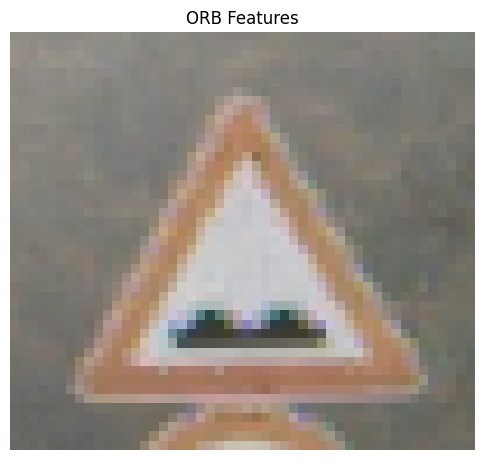

In [12]:
orb = cv2.ORB_create(nfeatures=500)

kp,des = orb.detectAndCompute(gray,None)

orb_img = cv2.drawKeypoints(image,kp,None,color=(0,255,0))

plt.figure(figsize=(6,6))
plt.imshow(orb_img)
plt.title("ORB Features")
plt.axis("off")

print("ORB Keypoints:",len(kp))
if des is not None:
    print("Descriptor Shape:",des.shape)
else:
    print("No descriptors found (des is None)")

In [15]:
try:
    star = cv2.xfeatures2d.StarDetector_create()
    kp_initial = star.detect(gray,None)
    print("StarDetector detected", len(kp_initial), "keypoints.")
except AttributeError:
    print("StarDetector_create not found. Falling back to FAST detector.")
    fast = cv2.FastFeatureDetector_create()
    kp_initial = fast.detect(gray,None)
    print("FAST detected", len(kp_initial), "keypoints.")

try:
    brief = cv2.xfeatures2d.BriefDescriptorExtractor_create()
except AttributeError:
    print("BriefDescriptorExtractor_create not found. BRIEF descriptors cannot be computed.")
    brief = None


if kp_initial and brief: # Ensure keypoints were detected and brief is available before computing descriptors
    kp_final, des = brief.compute(gray, kp_initial)
    print("BRIEF Keypoints after descriptor computation:",len(kp_final))
    if des is not None:
        print("Descriptor Shape:",des.shape)
    else:
        print("No BRIEF descriptors found (des is None) for the detected keypoints.")
elif kp_initial and not brief:
    print("BRIEF descriptor extractor not available, skipping descriptor computation.")
else:
    print("No keypoints were detected by the chosen detector, so no BRIEF descriptors could be computed.")

StarDetector_create not found. Falling back to FAST detector.
FAST detected 33 keypoints.
BriefDescriptorExtractor_create not found. BRIEF descriptors cannot be computed.
BRIEF descriptor extractor not available, skipping descriptor computation.


In [16]:
second_image = None

count = 0

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".png"):
            count += 1
            if count == 2:
                second_image = os.path.join(root,file)
                break
    if second_image:
        break

print(second_image)

/root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1/train/22/00022_00005_00008.png


Text(0.5, 1.0, 'Test Image')

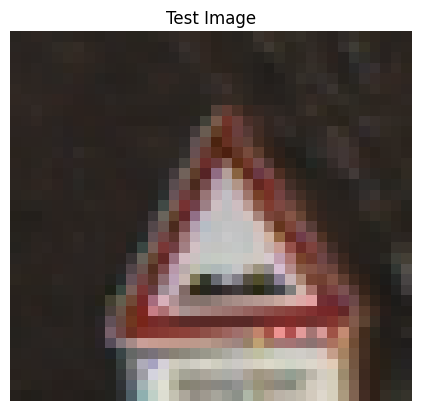

In [17]:
img2 = cv2.imread(second_image)

img2 = cv2.cvtColor(img2,cv2.COLOR_BGR2RGB)

gray2 = cv2.cvtColor(img2,cv2.COLOR_RGB2GRAY)

plt.imshow(img2)
plt.axis("off")
plt.title("Test Image")

In [18]:
orb = cv2.ORB_create()

kp1,des1 = orb.detectAndCompute(gray,None)

kp2,des2 = orb.detectAndCompute(gray2,None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING,crossCheck=True)

matches = bf.match(des1,des2)

matches = sorted(matches,key=lambda x:x.distance)

Text(0.5, 1.0, 'ORB Feature Matching')

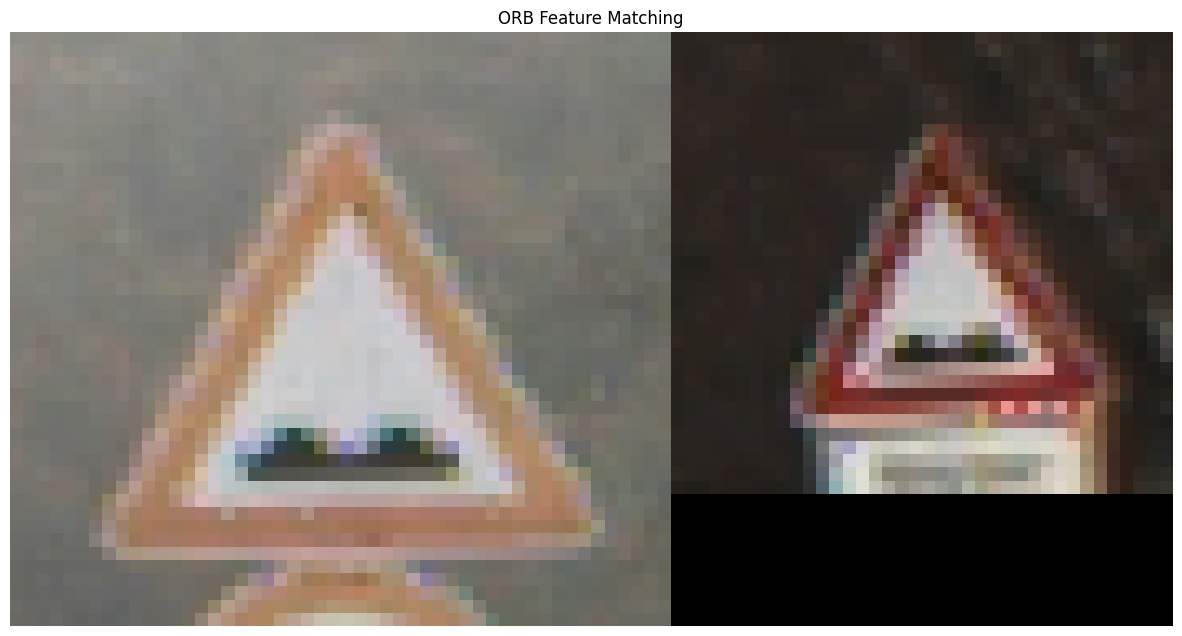

In [19]:
matched = cv2.drawMatches(image,kp1,img2,kp2,matches[:30],None,flags=2)

plt.figure(figsize=(15,8))
plt.imshow(matched)
plt.axis("off")
plt.title("ORB Feature Matching")

In [20]:
good_matches = [m for m in matches if m.distance < 45]

print("Good Matches:",len(good_matches))

if len(good_matches) > 20:
    print("Road Sign Recognized")
else:
    print("Road Sign Not Recognized")

Good Matches: 0
Road Sign Not Recognized


In [21]:
# Sort matches (lower distance = better match)
matches = sorted(matches, key=lambda x: x.distance)

print("Total Matches:", len(matches))

Total Matches: 0


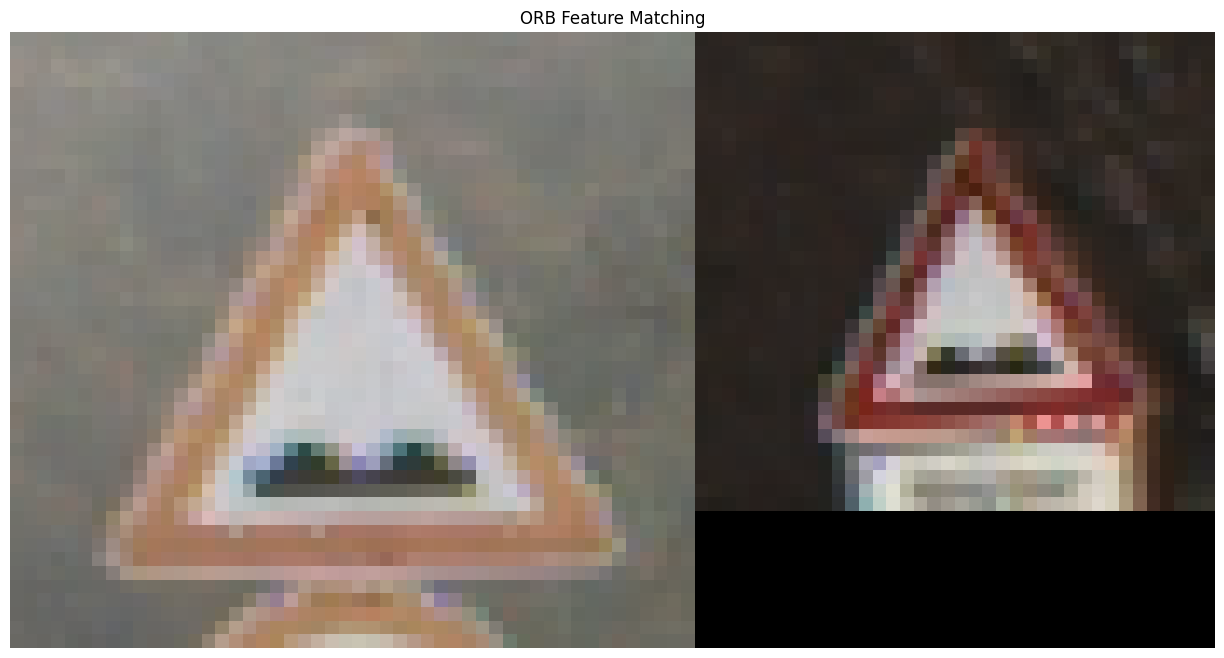

In [22]:
matched_image = cv2.drawMatches(
    image, kp1,
    img2, kp2,
    matches[:40],      # Show top 40 matches
    None,
    flags=2
)

plt.figure(figsize=(18,8))
plt.imshow(matched_image)
plt.title("ORB Feature Matching")
plt.axis("off")
plt.show()

In [23]:
good_matches = [m for m in matches if m.distance < 40]

print("Good Matches:", len(good_matches))

Good Matches: 0


In [24]:
if len(good_matches) >= 20:
    print("Road Sign Recognized Successfully")
else:
    print("Road Sign Not Recognized")

Road Sign Not Recognized


In [26]:
if len(matches) > 0:
    matching_percentage = (len(good_matches) / len(matches)) * 100
    print(f"Matching Percentage: {matching_percentage:.2f}%")
else:
    print("No matches were found between the images, so matching percentage is 0.00%.")
    matching_percentage = 0.0

No matches were found between the images, so matching percentage is 0.00%.


---------- FINAL RESULT ----------
Total Keypoints (Reference): 0
Total Keypoints (Test): 0
Total Matches: 0
Good Matches: 0
Matching Percentage: 0.00%
Prediction: DIFFERENT Road Sign


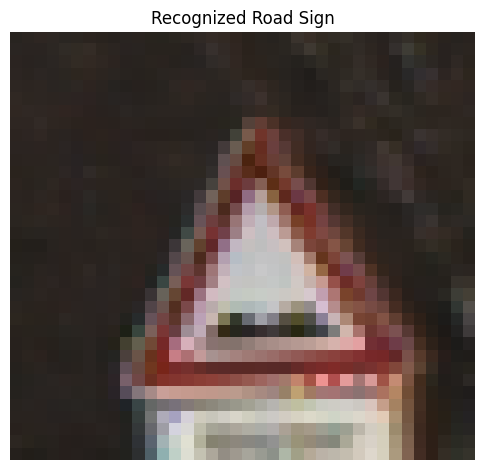

In [27]:
plt.figure(figsize=(6,6))
plt.imshow(img2)
plt.title("Recognized Road Sign")
plt.axis("off")

print("---------- FINAL RESULT ----------")
print("Total Keypoints (Reference):", len(kp1))
print("Total Keypoints (Test):", len(kp2))
print("Total Matches:", len(matches))
print("Good Matches:", len(good_matches))
print(f"Matching Percentage: {matching_percentage:.2f}%")

if matching_percentage > 30:
    print("Prediction: SAME Road Sign")
else:
    print("Prediction: DIFFERENT Road Sign")